In [ ]:
# create the tavily search tool and code executor tool for the multi-agent system

In [1]:
import logging
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.types import Command
from typing_extensions import Literal
from langchain_tavily import TavilySearch
from langchain_experimental.utilities import PythonREPL
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent

In [2]:
import os
tavily_api_key=os.getenv("TAVILY_API_KEY")
tavily_search_tool = TavilySearch(
    tavily_api_key=tavily_api_key,
)

In [3]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger(__name__)

In [4]:
python_repl_tool = PythonREPL()

In [5]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, api_key=os.getenv("OPENAI_API_KEY"))

In [6]:
# In main supervisor node we have to route to the nodes accordingly 

class Router:
    next: Literal["researcher_node", "code_executor_node", "code_generator_node","__end__"]

In [24]:
from langgraph.graph import MessagesState,StateGraph,START, END
from langchain_core.messages import HumanMessage, AIMessage

members=["researcher_node", "code_executor_node", "code_generator_node"]
supervisor_prompt = f"""
You are a supervisor, tasked with managing a conversation between the following workers: {members}.

Given the following user request, respond with the worker to act next. 
Each worker will perform a task and respond with their results and status. 

Your responsibilities:
1. Choose the most appropriate worker out of the provided members for the next step.
2. If research has been completed by the Researcher, you MUST pass the output to the Code Generator.
3. The Code Generator must return Python code in this exact format:

my_code = \"\"\"
<your generated python code here>
\"\"\"

4. Once the code is generated, you MUST pass it to the Code Executor for execution.
5. When the overall workflow is complete, respond with "__end__".

Return ONLY in the following JSON format:
{{
   "next" : <member_id>
}}
"""

In [25]:
def supervisor_node(state: MessagesState) -> Command[Literal["researcher_node", "code_executor_node", "code_generator_node", END]]:
    """
    Supervisor uses LLM to decide the next node dynamically.
    """
    logger.info("[Supervisor] Deciding next step with LLM...")

    system_prompt = supervisor_prompt

    # Combine the system prompt + existing messages
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]

    print("supervisor",messages, " -----")

    # Make the LLM output structured according to Router
    llm_with_structure_output = llm.with_structured_output(Router)
    response = llm_with_structure_output.invoke(messages)

    print("response from supervisor",response)

    # logger.info(f"[Supervisor] LLM decided next step: {response["next"]}")

    return Command(goto=response["next"], update={"next":response["next"]})

In [26]:
def researcher_node(state: MessagesState) -> Command[Literal["supervisor_node"]]:
    """Research information and pass results forward."""
    logger.info("[Researcher] Received state: %s", state)

    researcher_agent = create_react_agent(
        model=llm,
        tools=[tavily_search_tool],
        prompt="Run researches on the provided data"
    )

    result = researcher_agent.invoke(state)
    logger.info("[Researcher] Search result: %s", result)
    print("response from researcher", result)

    return Command(
        goto="supervisor_node",
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="researcher_node")]}
    )


def code_generator_node(state: MessagesState) -> Command[Literal["supervisor_node"]]:
    """Generate Python code based on research results."""
    logger.info("[Code Generator] Received state: %s", state)

    code_gen_agent = create_react_agent(model=llm, tools=[], prompt = "Generate Python code to process the research data above.")
    result = code_gen_agent.invoke(state)
    print("response from [Code Generator]", result)

    logger.info("[Code Generator] Generated code: %s", result)

    return Command(
        goto="supervisor_node",
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="researcher_node")]}
    )


def code_executor_node(state: MessagesState) -> Command[Literal["supervisor_node" ]]:
    """Execute generated code."""
    logger.info("[Code Executor] Received state: %s", state)

    exec_agent = create_react_agent(model=llm, tools=[python_repl_tool], prompt="Execute the code")
    result = exec_agent.invoke(state)
    print("response from code executor", result)
    logger.info("[Code Executor] Execution result: %s", result)

    return Command(
        goto="supervisor_node",
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="researcher_node")]}
    )



In [27]:
graph = StateGraph(MessagesState)

graph.add_node("supervisor_node", supervisor_node)
graph.add_node("researcher_node", researcher_node)
graph.add_node("code_generator_node", code_generator_node)
graph.add_node("code_executor_node", code_executor_node)

In [28]:
graph.add_edge(START, "supervisor_node")

In [30]:
app = graph.compile()

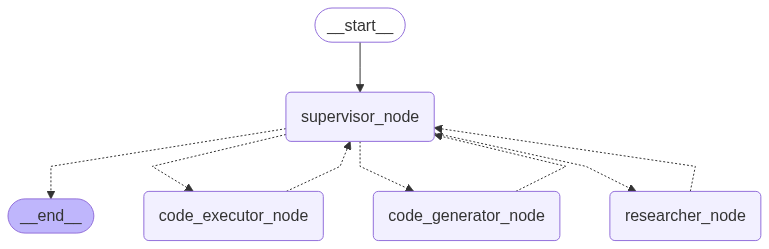

In [ ]:
from IPython.display import display, Image
# from langgraph.graph import MermaidDrawMethod

# Assuming `app` is your compiled StateGraph
graph_png = app.get_graph().draw_mermaid_png(
    # draw_method=MermaidDrawMethod.PYPPETEER
)

display(Image(graph_png))

In [ ]:
%pip install pyppeteer


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.9/82.9 kB 160.9 kB/s eta 0:00:00a 0:00:01
  Using cached appdirs-1.4.4-py2.py3-none-any.whl (9.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 1.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.9/97.9 kB 870.4 kB/s eta 0:00:00 0:00:01
  Attempting uninstall: websockets
    Found existing installation: websockets 15.0.1
    Uninstalling websockets-15.0.1:
      Successfully uninstalled websockets-15.0.1
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.4.0
    Uninstalling urllib3-2.4.0:
      Successfully uninstalled urllib3-2.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
yfinance 0.2.63 requires websockets>=13.0, but you have websockets 10.4 which is incompatible.

[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To up

In [ ]:
graph_png = app.get_graph().draw_mermaid_png(
    max_retries=5,
    retry_delay=2.0
)

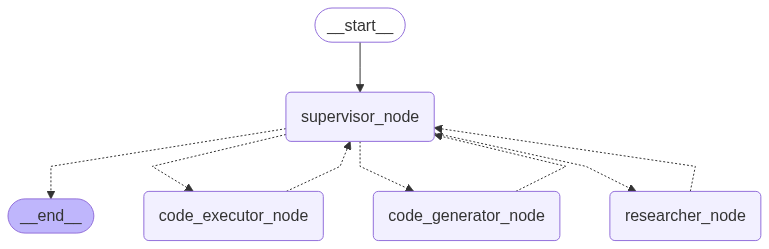

In [ ]:
display(Image(graph_png))

In [32]:
from langchain_core.messages import HumanMessage

for s in app.stream({"messages": [("user", "GDP Growth of India from 2020 to 2022, generate line chart for the same")]}, subgraphs=True):
    print(s)
    print("**********BELOW IS MY STATE***************")

2025-08-13 19:23:26,137 | INFO | [Supervisor] Deciding next step with LLM...


supervisor [{'role': 'system', 'content': '\nYou are a supervisor, tasked with managing a conversation between the following workers: [\'researcher_node\', \'code_executor_node\', \'code_generator_node\'].\n\nGiven the following user request, respond with the worker to act next. \nEach worker will perform a task and respond with their results and status. \n\nYour responsibilities:\n1. Choose the most appropriate worker out of the provided members for the next step.\n2. If research has been completed by the Researcher, you MUST pass the output to the Code Generator.\n3. The Code Generator must return Python code in this exact format:\n\nmy_code = """\n<your generated python code here>\n"""\n\n4. Once the code is generated, you MUST pass it to the Code Executor for execution.\n5. When the overall workflow is complete, respond with "__end__".\n\nReturn ONLY in the following JSON format:\n{\n   "next" : <member_id>\n}\n'}, HumanMessage(content='GDP Growth of India from 2020 to 2022, genera

2025-08-13 19:23:28,500 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-08-13 19:23:28,507 | INFO | [Researcher] Received state: {'messages': [HumanMessage(content='GDP Growth of India from 2020 to 2022, generate line chart for the same', additional_kwargs={}, response_metadata={}, id='bd03f664-b7c1-41d6-9376-28601718beb6')]}


response from supervisor {'next': 'researcher_node'}
((), {'supervisor_node': None})
**********BELOW IS MY STATE***************


2025-08-13 19:23:33,007 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

2025-08-13 19:26:02,345 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-08-13 19:26:02,363 | INFO | [Code Generator] Generated code: {'messages': [HumanMessage(content='GDP Growth of India from 2020 to 2022, generate line chart for the same', additional_kwargs={}, response_metadata={}, id='bd03f664-b7c1-41d6-9376-28601718beb6'), HumanMessage(content="The GDP growth rates of India from 2020 to 2022 are as follows:\n\n- **2020**: -5.78%\n- **2021**: 9.69%\n- **2022**: 6.99%\n\nNow, let's generate a line chart to visualize this data. \n\n```python\nimport matplotlib.pyplot as plt\n\n# Data\nyears = [2020, 2021, 2022]\ngdp_growth = [-5.78, 9.69, 6.99]\n\n# Create line chart\nplt.figure(figsize=(10, 5))\nplt.plot(years, gdp_growth, marker='o')\nplt.title('GDP Growth of India (2020-2022)')\nplt.xlabel('Year')\nplt.ylabel('GDP Growth Rate (%)')\nplt.xticks(years)\nplt.grid()\nplt.axhline(0, color='grey', lw=0.8, ls='--')\nplt.show()\n```\n\nThis c

(('code_generator_node:ac047d98-bfc5-7879-2a39-7456b75243c6',), {'agent': {'messages': [AIMessage(content="The provided Python code is indeed well-structured for generating a line chart to visualize the GDP growth rates of India from 2020 to 2022. Below is the code again for clarity, along with a brief explanation of each part:\n\n```python\nimport matplotlib.pyplot as plt\n\n# Data\nyears = [2020, 2021, 2022]\ngdp_growth = [-5.78, 9.69, 6.99]\n\n# Create line chart\nplt.figure(figsize=(10, 5))\nplt.plot(years, gdp_growth, marker='o', color='b', linestyle='-')\nplt.title('GDP Growth of India (2020-2022)')\nplt.xlabel('Year')\nplt.ylabel('GDP Growth Rate (%)')\nplt.xticks(years)\nplt.grid()\nplt.axhline(0, color='grey', lw=0.8, ls='--')  # Horizontal line at y=0\nplt.ylim(-10, 15)  # Set y-axis limits for better visualization\nplt.show()\n```\n\n### Explanation of the Code:\n- **Importing Libraries**: The code imports the `matplotlib.pyplot` library, which is essential for creating visu

2025-08-13 19:26:03,206 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


response from supervisor {'next': 'code_generator_node'}
((), {'supervisor_node': None})
**********BELOW IS MY STATE***************


GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/GRAPH_RECURSION_LIMIT

In [36]:
%pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 1.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.1/270.1 kB 2.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 2.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 3.5 MB/s eta 0:00:00
  Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)

[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [37]:

python_code = """
import matplotlib.pyplot as plt\n\n# Data\nyears = [2020, 2021, 2022]\ngdp_growth = [-5.78, 9.69, 6.99]\n\n# Create line chart\nplt.figure(figsize=(10, 5))\nplt.plot(years, gdp_growth, marker='o')\nplt.title('GDP Growth of India (2020-2022)')\nplt.xlabel('Year')\nplt.ylabel('GDP Growth Rate (%)')\nplt.xticks(years)\nplt.grid()\nplt.axhline(0, color='grey', lw=0.8, ls='--')\nplt.show()"""

2025-08-13 19:27:07,065 | WARNING | Matplotlib is building the font cache; this may take a moment.
2025-08-13 19:27:19,328 | INFO | Failed to extract font properties from /System/Library/Fonts/Apple Color Emoji.ttc: Could not set the fontsize (invalid pixel size; error code 0x17)
2025-08-13 19:27:19,336 | INFO | Failed to extract font properties from /System/Library/Fonts/LastResort.otf: tuple indices must be integers or slices, not str
2025-08-13 19:27:19,366 | INFO | Failed to extract font properties from /System/Library/Fonts/ZitherIndia.otf: Can not load face (SFNT font table missing; error code 0x8e)
2025-08-13 19:27:19,446 | INFO | Failed to extract font properties from /System/Library/PrivateFrameworks/FontServices.framework/Resources/Reserved/PingFangUI.ttc: Can not load face (locations (loca) table missing; error code 0x90)
2025-08-13 19:27:19,459 | INFO | Failed to extract font properties from /System/Library/Fonts/ZitherIndiaNarrow.otf: Can not load face (SFNT font table mis

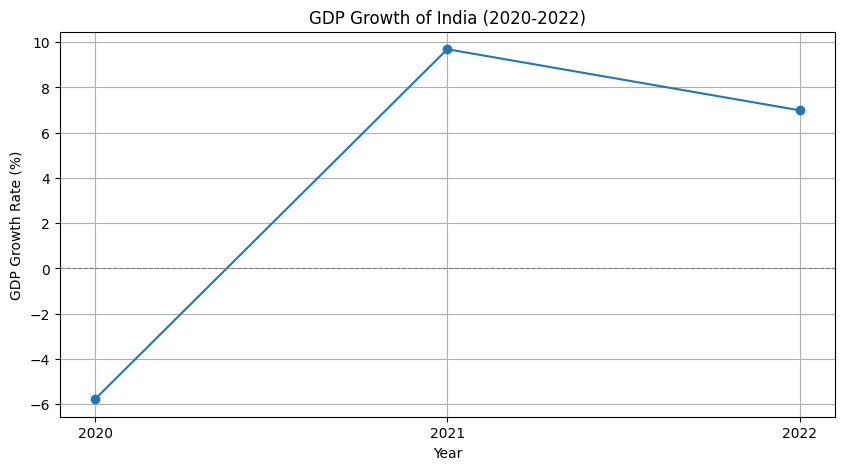

''

In [38]:
python_repl_tool.run(python_code)